### **For this assignment the only permitted libraries to use are Numpy, Scipy, MatplotLib and Pandas! All four have been imported for you in this Notebook.**

In [2]:
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data loading

Train and Test sets can be found in the `Resources` folder. You can choose to visualize your data all at once, in windows, or only considering a subset of sensors to detect which ones would prove most useful to your analysis.
An example of such a visualization can be found in the following cell.

In [3]:
train_file_path = 'Resources/lab1_train.csv'
test_file_path = 'Resources/lab1_test.csv'

train_data = pd.read_csv(train_file_path, delimiter=',')
test_data = pd.read_csv(test_file_path, delimiter=',')

# Convert Timestamp column to datetime
train_data['Timestamp'] = pd.to_datetime(train_data['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
test_data['Timestamp'] = pd.to_datetime(test_data['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')

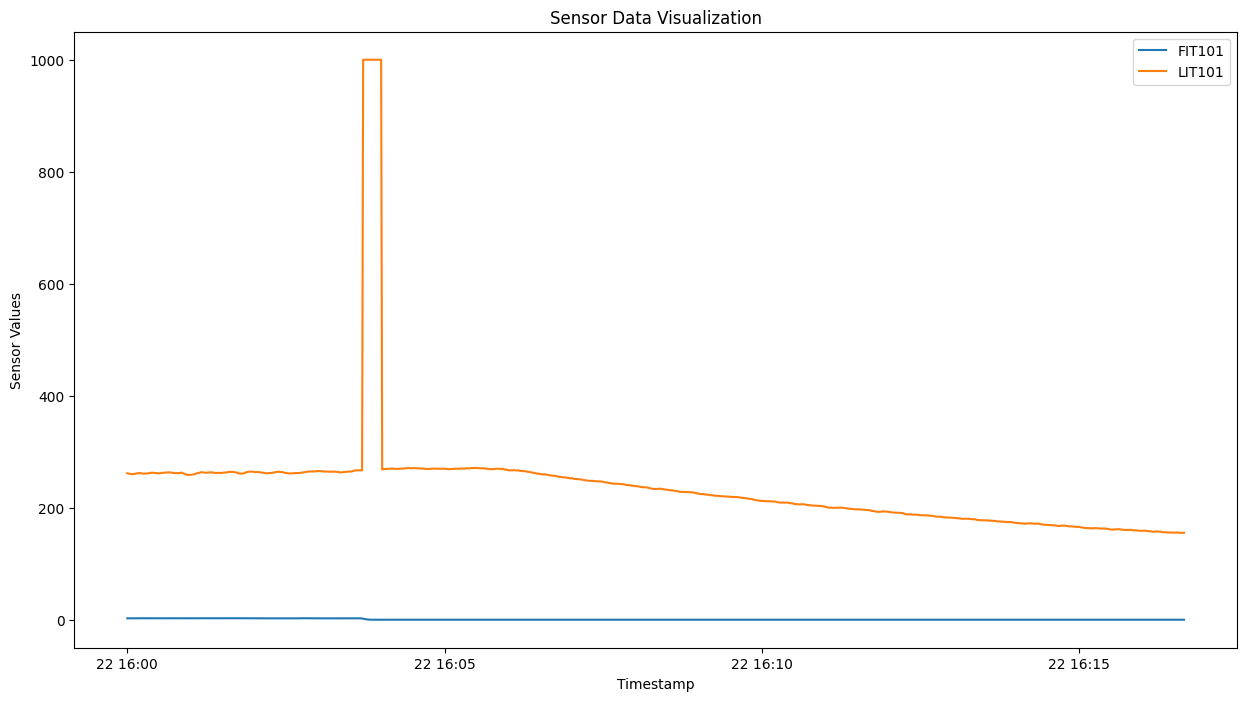

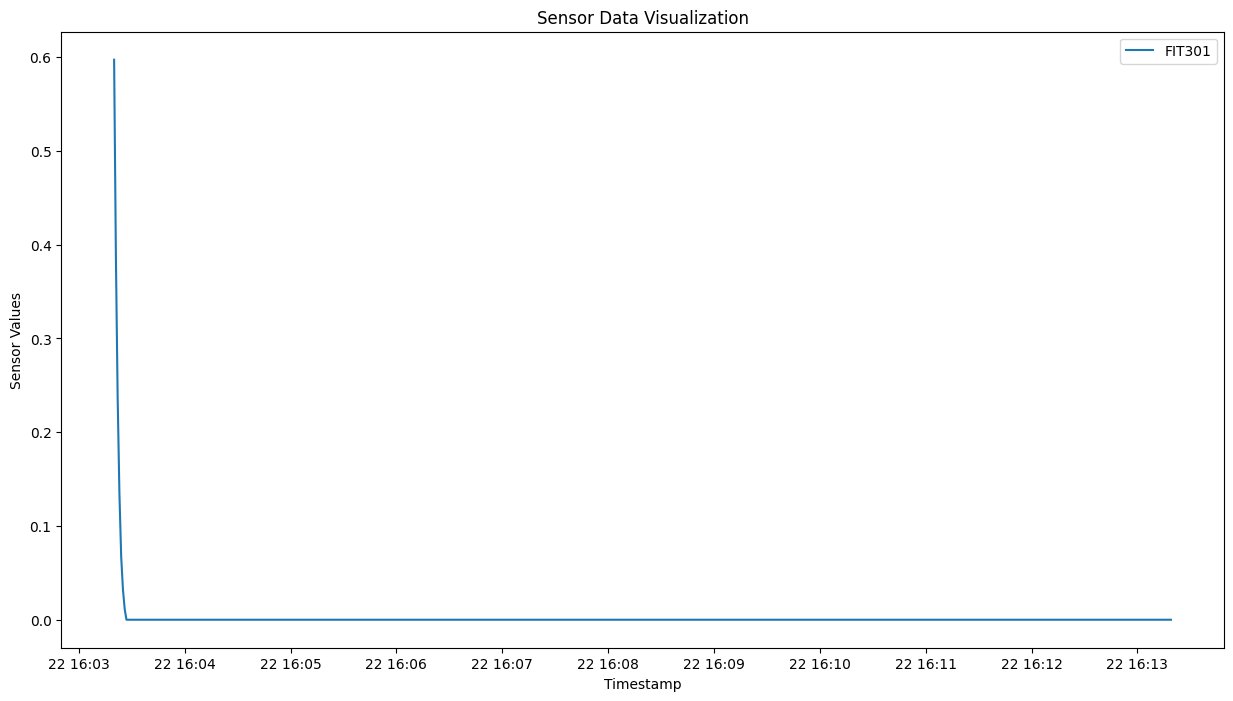

/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


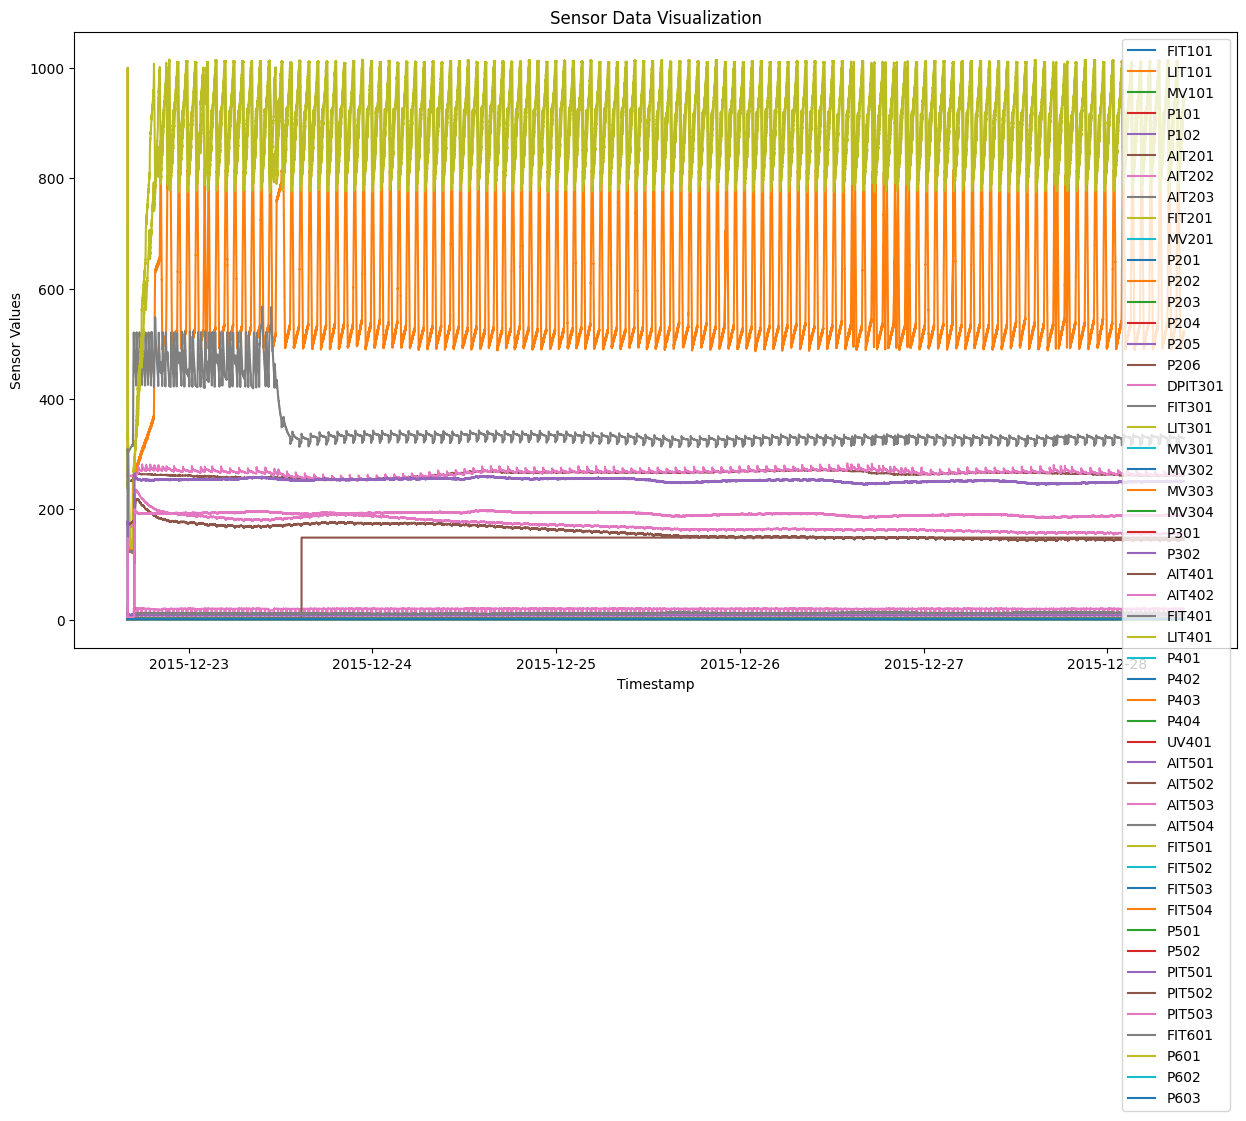

In [4]:
def visualize_sensor_data(df, window=None, sensors=None):
    # If window is None, visualize the entire dataset
    if window is None:
        start_index, end_index = 0, len(df)
    else:
        start_index, end_index = window

    # If sensors is None, select all sensor columns
    if sensors is None:
        sensors = df.columns[1:-1]

    # Plot each sensor in a different color
    plt.figure(figsize=(15, 8))
    for sensor in sensors:
        plt.plot(df['Timestamp'][start_index:end_index], df[sensor][start_index:end_index], label=sensor)

    plt.xlabel('Timestamp')
    plt.ylabel('Sensor Values')
    plt.title('Sensor Data Visualization')
    plt.legend()

    plt.show()

visualize_sensor_data(train_data, window=(0, 1000), sensors=['FIT101', 'LIT101'])
visualize_sensor_data(train_data, window=(200, 800), sensors=['FIT301'])
visualize_sensor_data(train_data)

# Familiarization

### 1. What types of signals are there?

#### a) Sensor AIT203

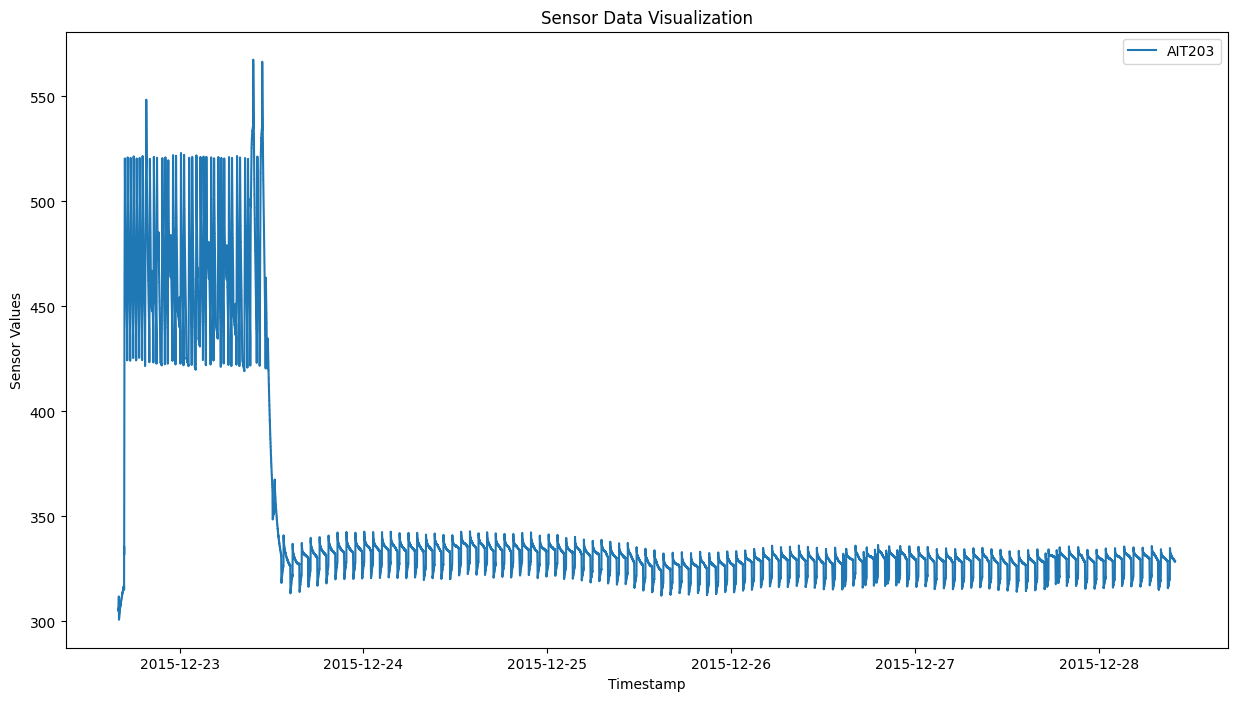

In [5]:
visualize_sensor_data(train_data, sensors=['AIT203'])

The **AIT203** sensor exhibits a clear two-regime behaviour with a transition point around December 23-24. The signal transitions from high-amplitude oscilations to more stable low-amplitude oscilations.

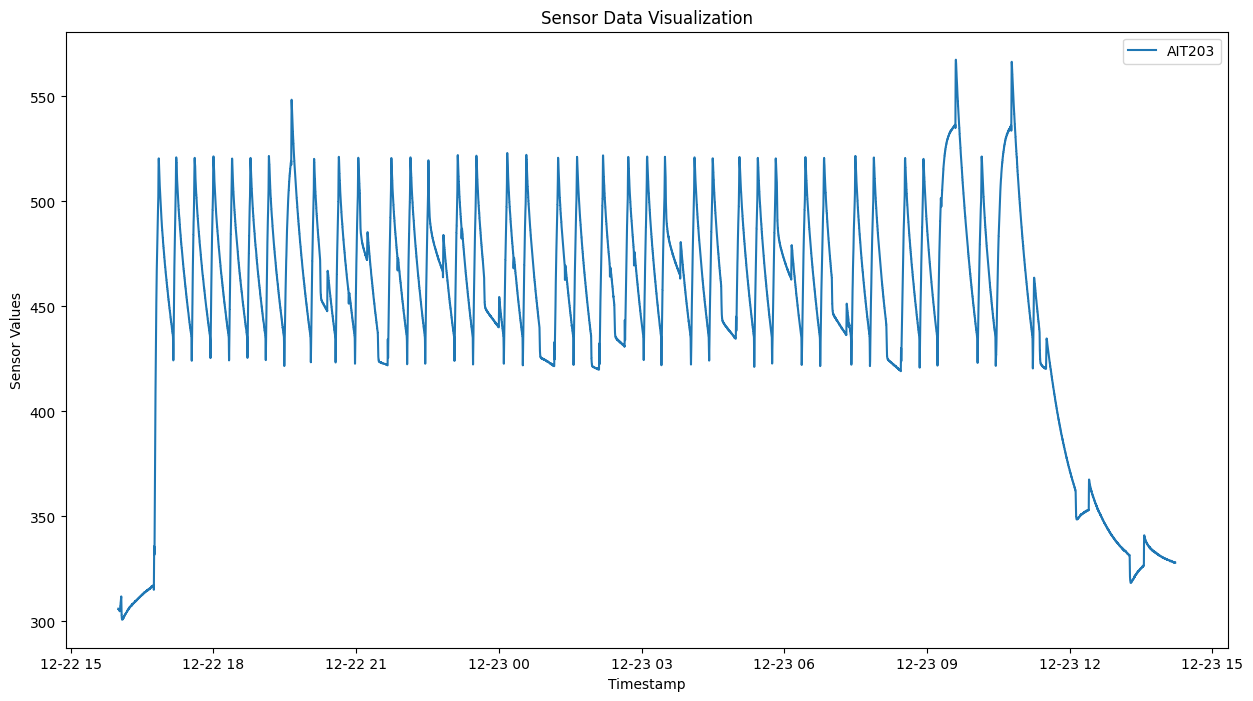

In [6]:
visualize_sensor_data(train_data, window=(0, 80000), sensors=['AIT203'])

Pattern 1 shows *cyclical behaviour* with oscilations between values 420 and 520 with occasional spikes reaching 550+. The amplitude range of aprox 130 units indicates high variance.

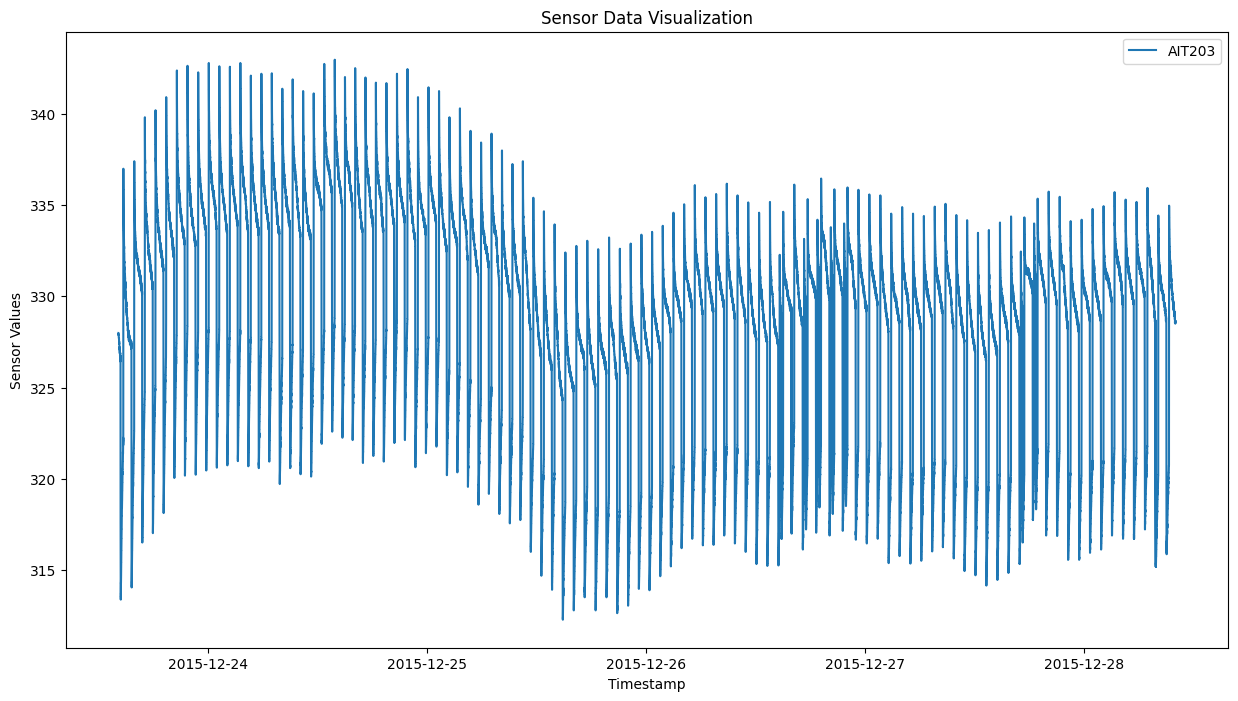

In [7]:
visualize_sensor_data(train_data, window=(80000, -1), sensors=['AIT203'])

The second pattern also shows *cyclical behavious* but with a lower baseline and more consistent oscialations variating from 310 to 350. 

#### b) Sensor P603

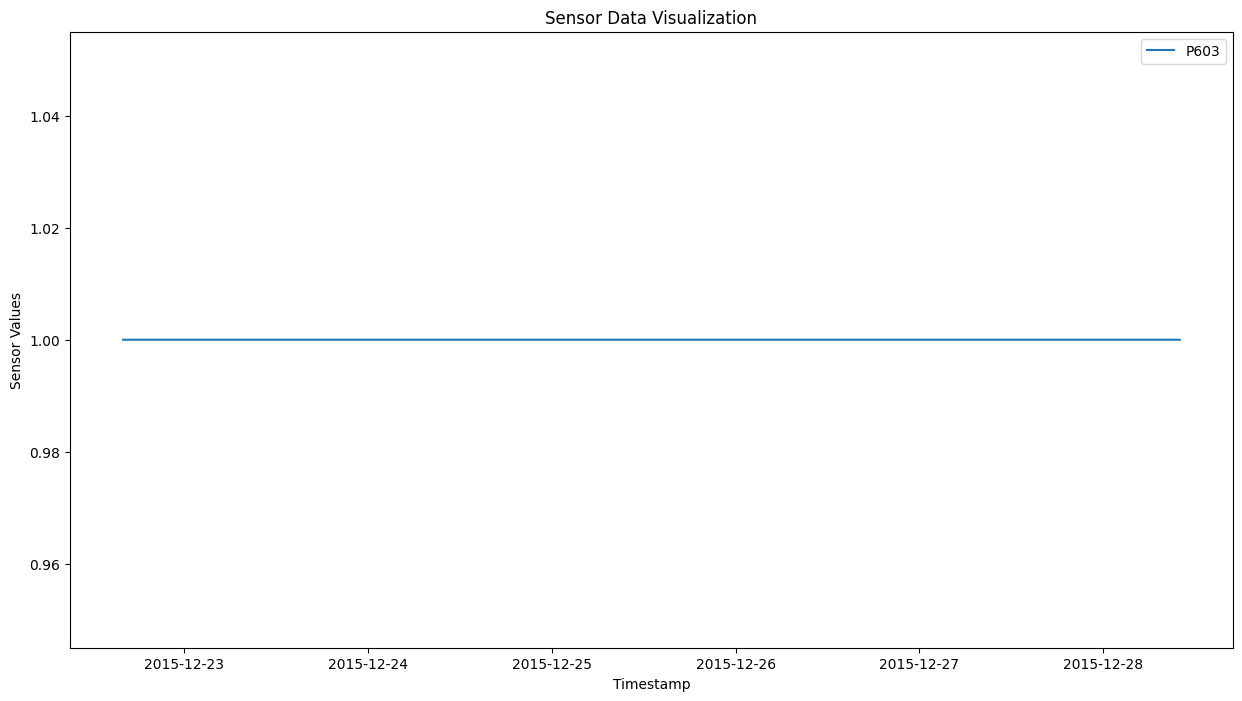

[1 1 1 ... 1 1 1]
496800


In [8]:
visualize_sensor_data(train_data, sensors=['P603'])

print(train_data["P603"].values)
print(len(train_data["P603"]))

The **P603** sensor displays a zero-variance signal, remaining flat at 1.00 throughout the entire time period. This shows that P603 is a *constant* sensor.

### 2. a) Are the signals correlated?

We first define a function that will make it easier to us to see whether 2 sensors are correlated or not.

In [9]:
def plot_correlation_matrix(df, window=[0, -1], sensors=None):
    # If window is None, visualize the entire dataset
    start_index, end_index = window

    if sensors is None:
        sensors = df.columns[1:-1]

    # Plot each sensor in a different color
    plt.figure(figsize=(15, 8))
    
    correlation_matrix = np.corrcoef(df[sensors][start_index:end_index].T)
    # correlation_matrix_clean = np.where(np.isnan(correlation_matrix), 0.0, correlation_matrix)

    plt.imshow(correlation_matrix)
    plt.colorbar()

    plt.xticks(ticks = range(len(sensors)), labels = sensors, rotation = 90)
    plt.yticks(ticks = range(len(sensors)), labels = sensors)

    plt.title('Correlation HeatMap')
    # plt.legend()

    plt.show()

Very simply, we get the corrcoef of every mentioned sensor with every other sensor in the provided array, over the given window size. Then, we filter out the NaNs (there are a bunch of them) and we plot using imshow(). Now that this is done, let's test it out. 

/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


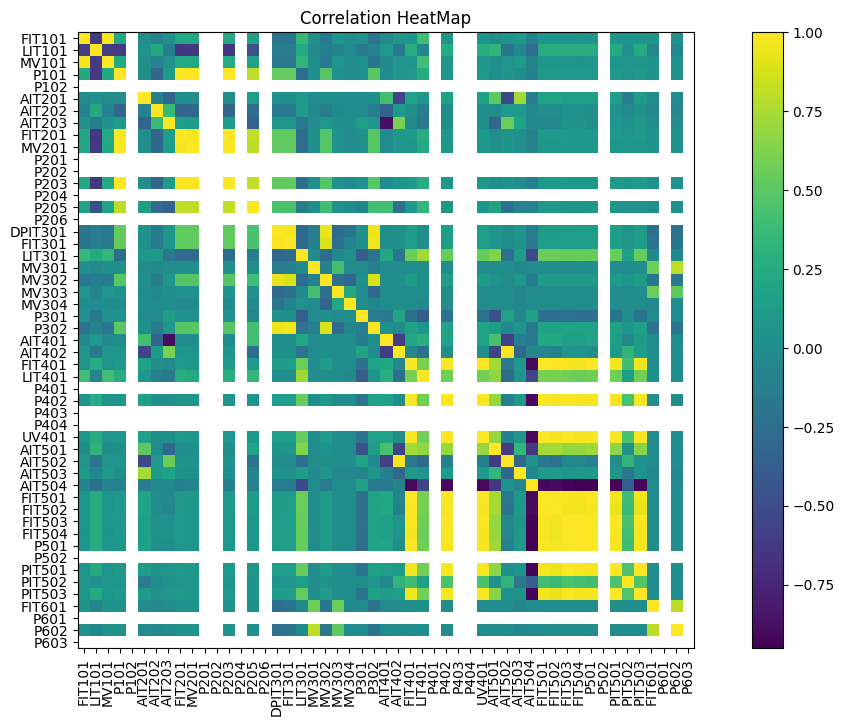

In [10]:
plot_correlation_matrix(train_data)

The grid cells with lighter colors means the 2 sensors corresponding to the row and the column are *positively correlated*, and with darker colors means they are *negatively correlated*.

Let's look at some positively correlated sensors, specifically **FIT501**, **FIT502**, **FIT503**, **FIT504**.

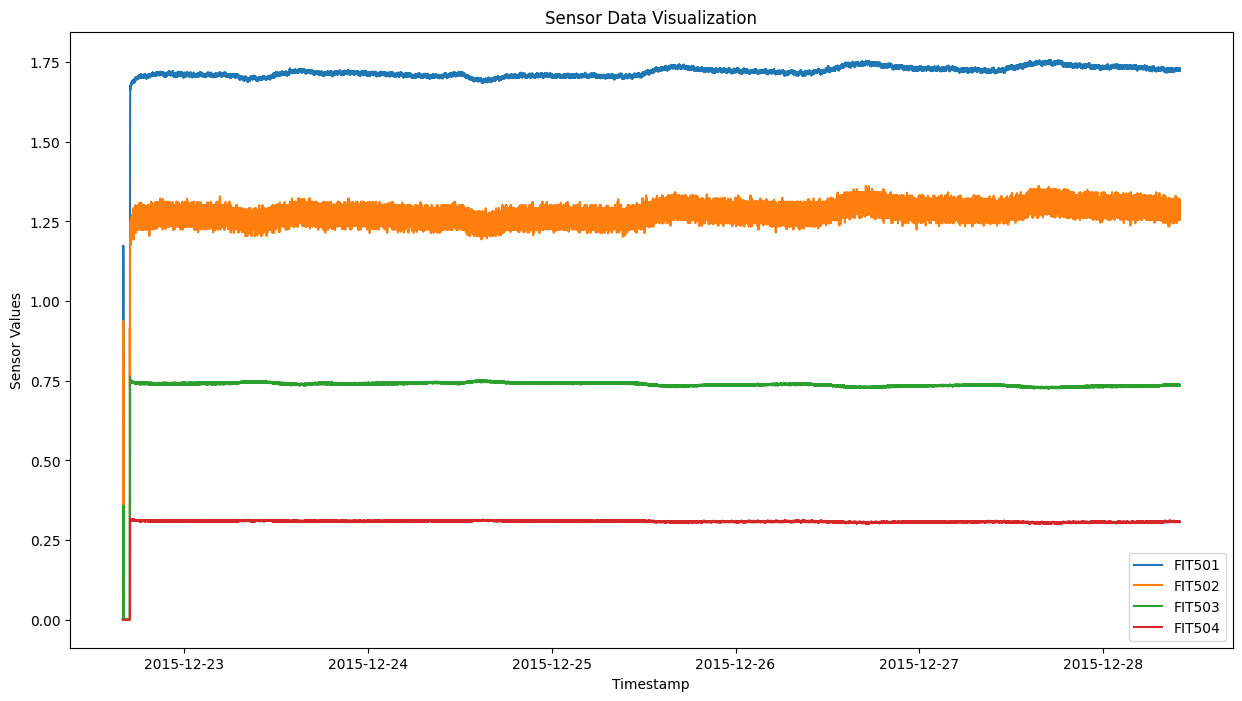

In [11]:
visualize_sensor_data(train_data, sensors = ["FIT501", "FIT502", "FIT503", "FIT504"])

They look like they're dependent on each other, but let's look even closer.

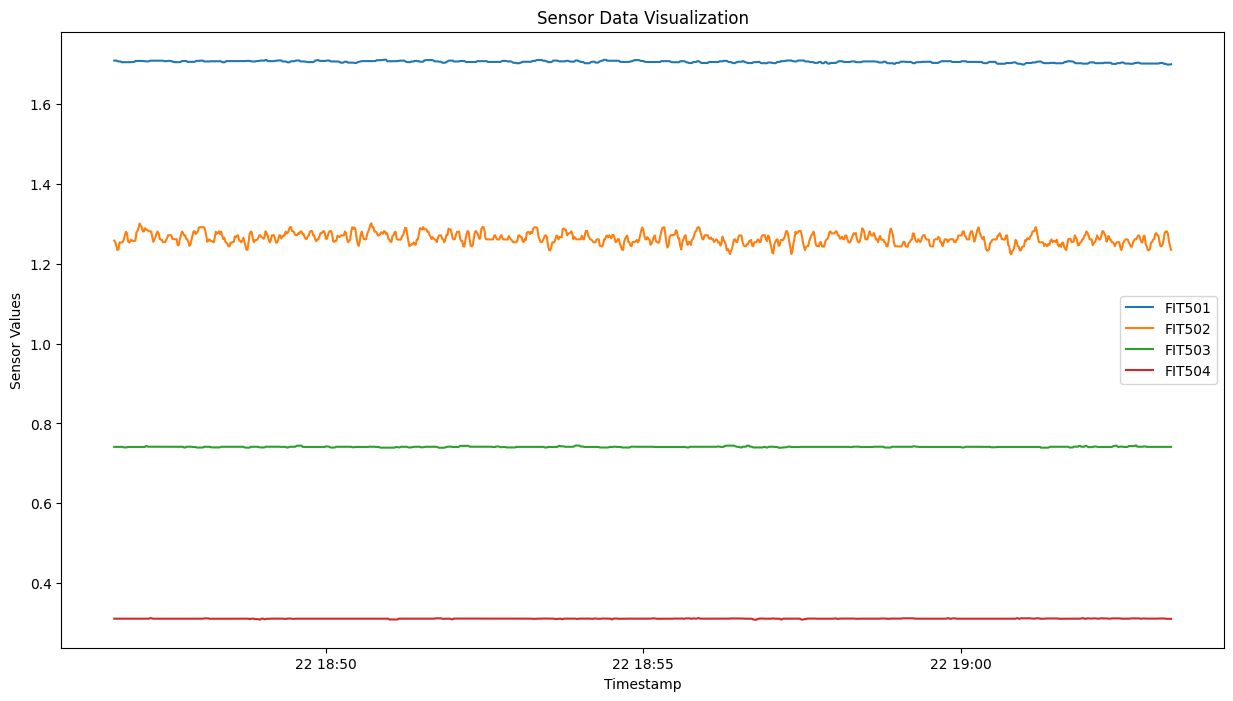

In [12]:
visualize_sensor_data(train_data, window = (10000, 11000), sensors = ["FIT501", "FIT502", "FIT503", "FIT504"])

This is interesting because the sensors are highly positively correlated even if the value of **FIT502** is noisy and the others are virtually constant.

Let's look at some negatively correlated sensors.

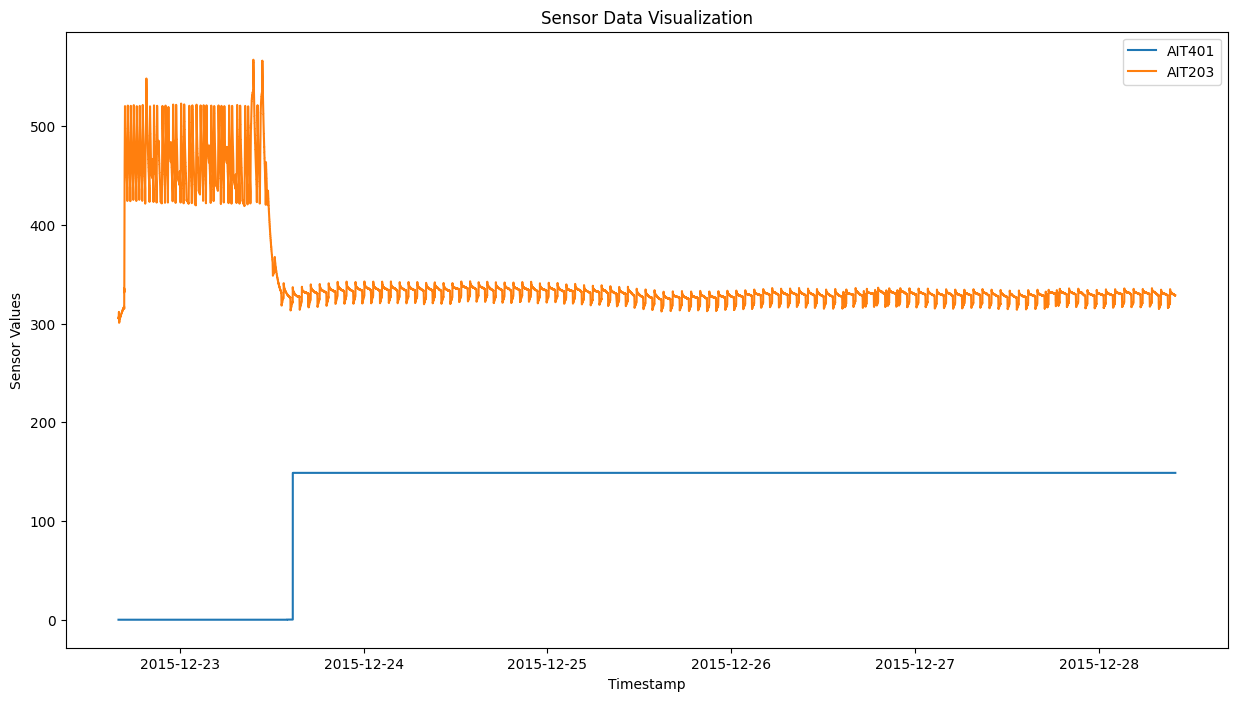

In [13]:
visualize_sensor_data(train_data, sensors = ["AIT401", "AIT203"])

This also makes a lot of sense because we can clearly see that because **AIT401** is mostly constant, it's sudden surge matters a lot to it's correlation with other sensors. Therefore, because **AIT203** drops when **AIT401** surges, we have a negative correlation.

It's easy to spot that there are also some completely white rows and columns. This is because in these cells, the value is NaN. Let's check some of these out!

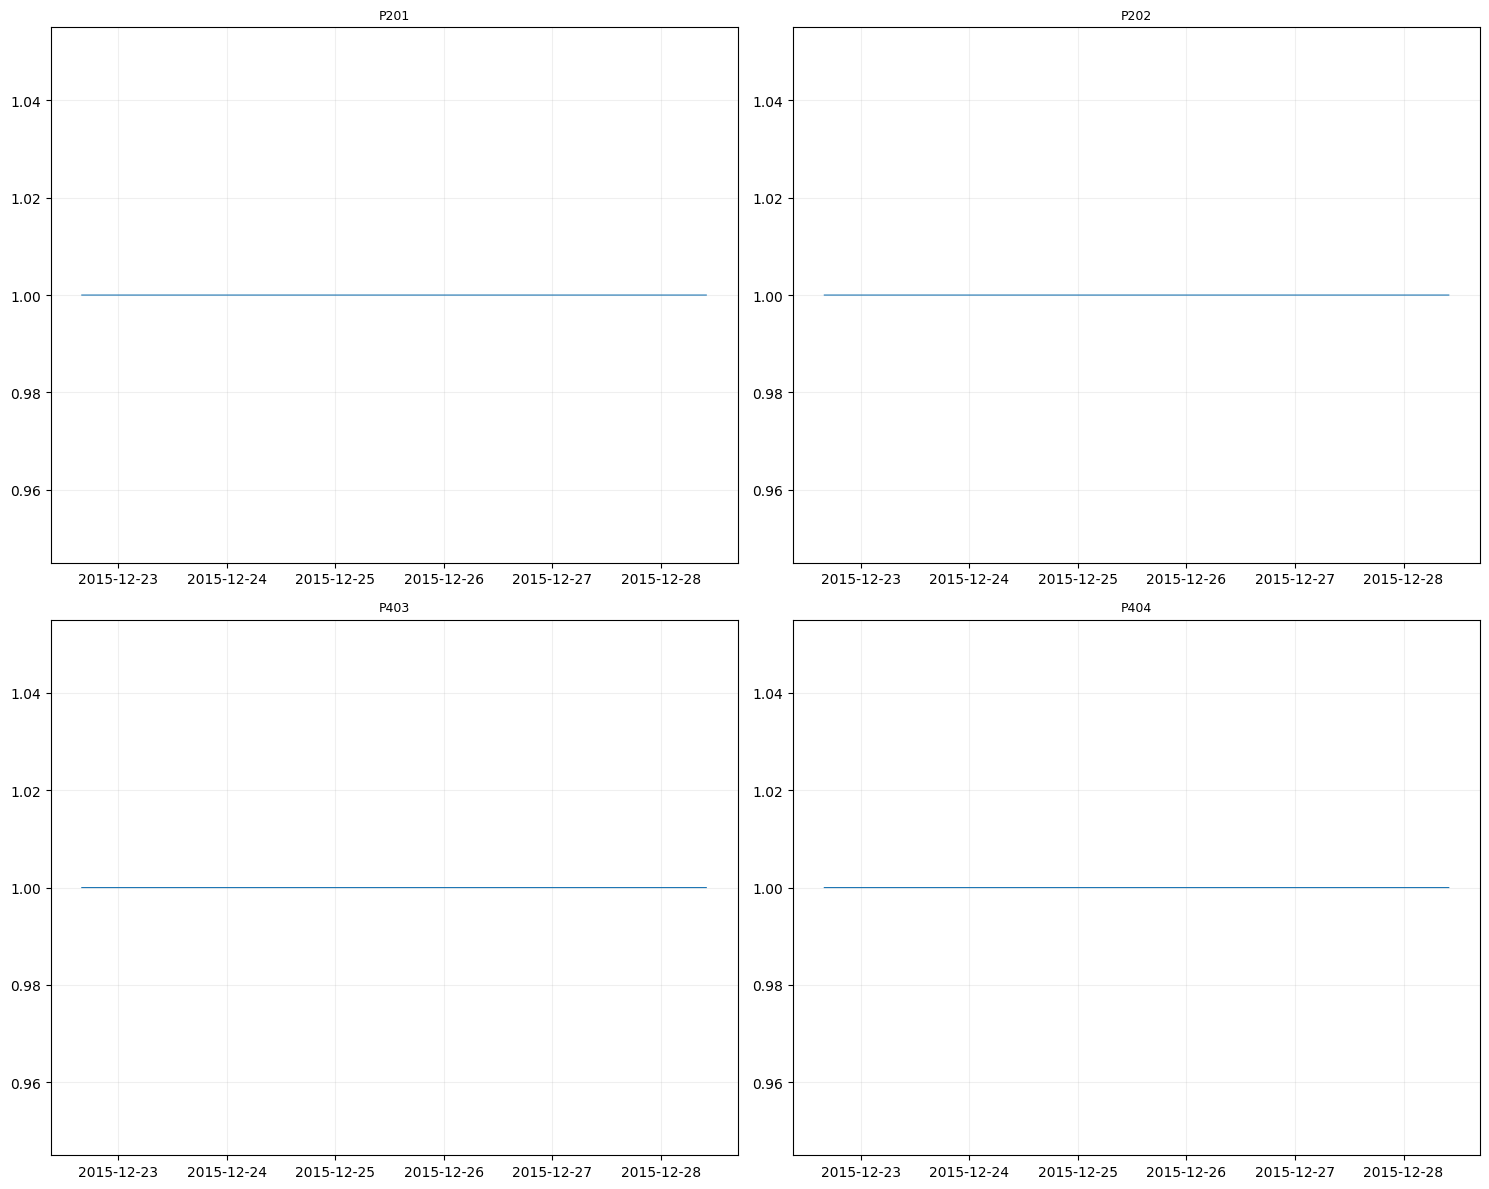

In [14]:
sensors = ["P201", "P202", "P403", "P404"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, ax in enumerate(axes):
    s = sensors[i]
    ax.plot(train_data['Timestamp'], train_data[s], linewidth=0.8)
    ax.set_title(s, fontsize=9)
    # ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    # ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
    ax.tick_params(axis='x')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


Let's zoom in into one of them.

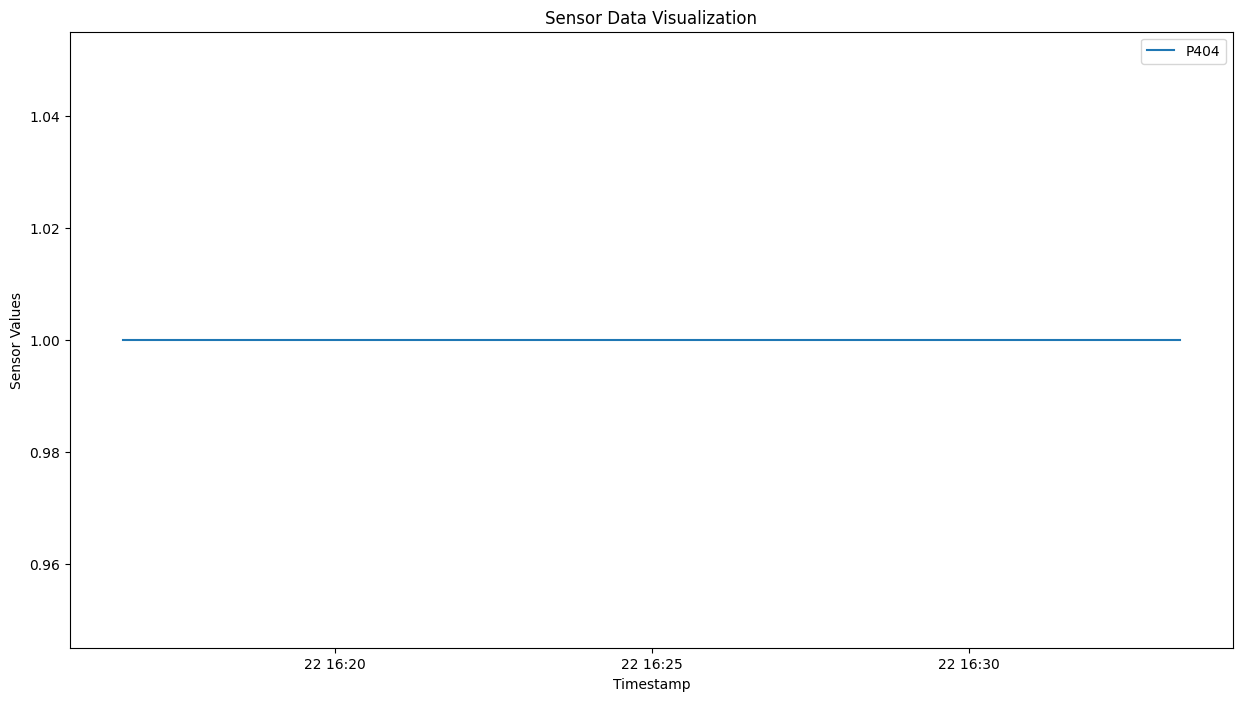

In [15]:
visualize_sensor_data(train_data, window = [1000, 2000], sensors = ["P404"])

The sensor is perfectly constant! That means it's standard deviation is 0, so this explains the NaN.

### b) Do they show cyclic behavior?

Even from the first plot showing all the sensors, it's clear that some sensors do show cyclic behavior. Some of them show this kind of behaviour across their entire sampling time, and others only over a part. Let's look at some interesting ones.

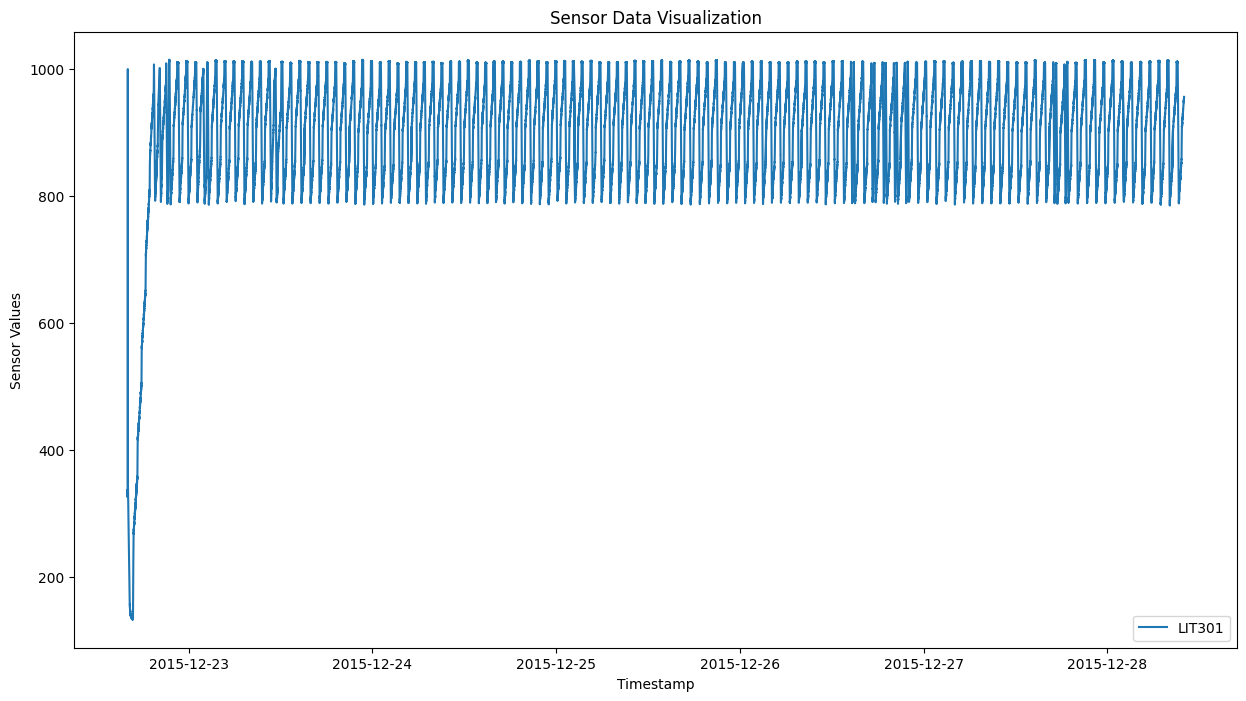

In [16]:
visualize_sensor_data(train_data, sensors = ["LIT301"])

The **LIT301** sensors clearly shows cyclic behavior. However, at the beginning we can see some different behaviour, which was probably the startup of the sensor/system.

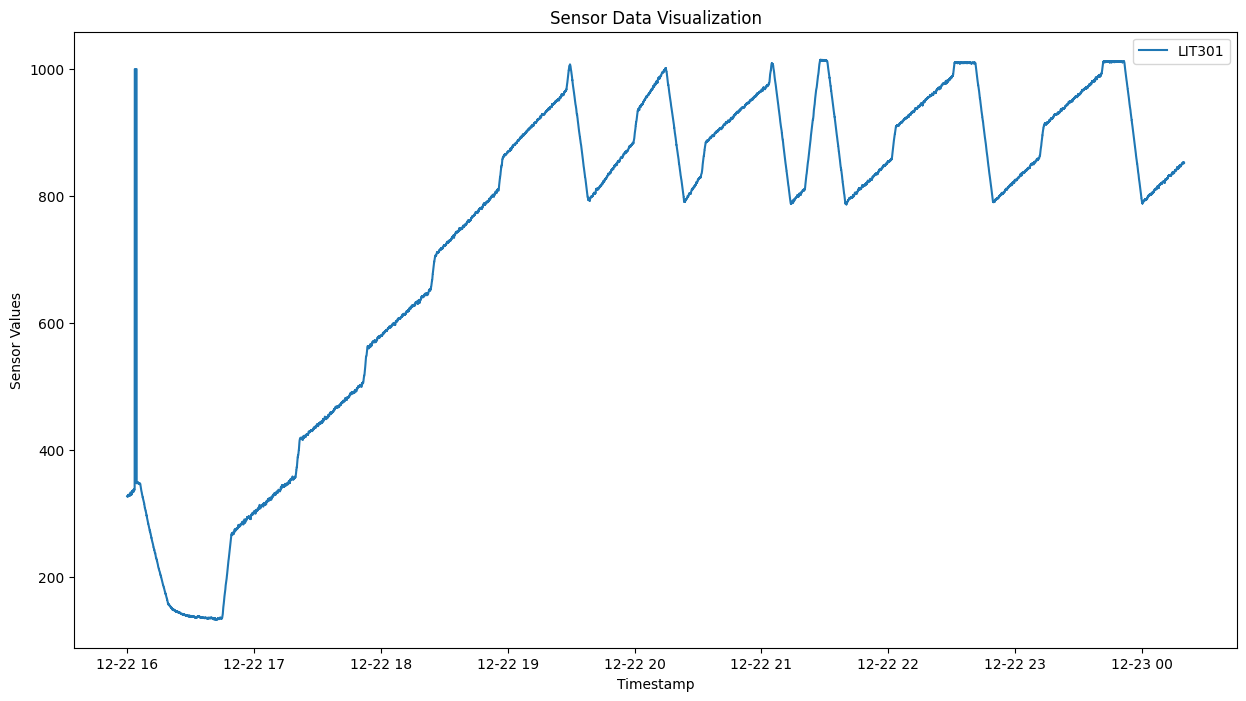

In [17]:
visualize_sensor_data(train_data, window = (0, 30000), sensors = ["LIT301"])

Let's look at another sensor.

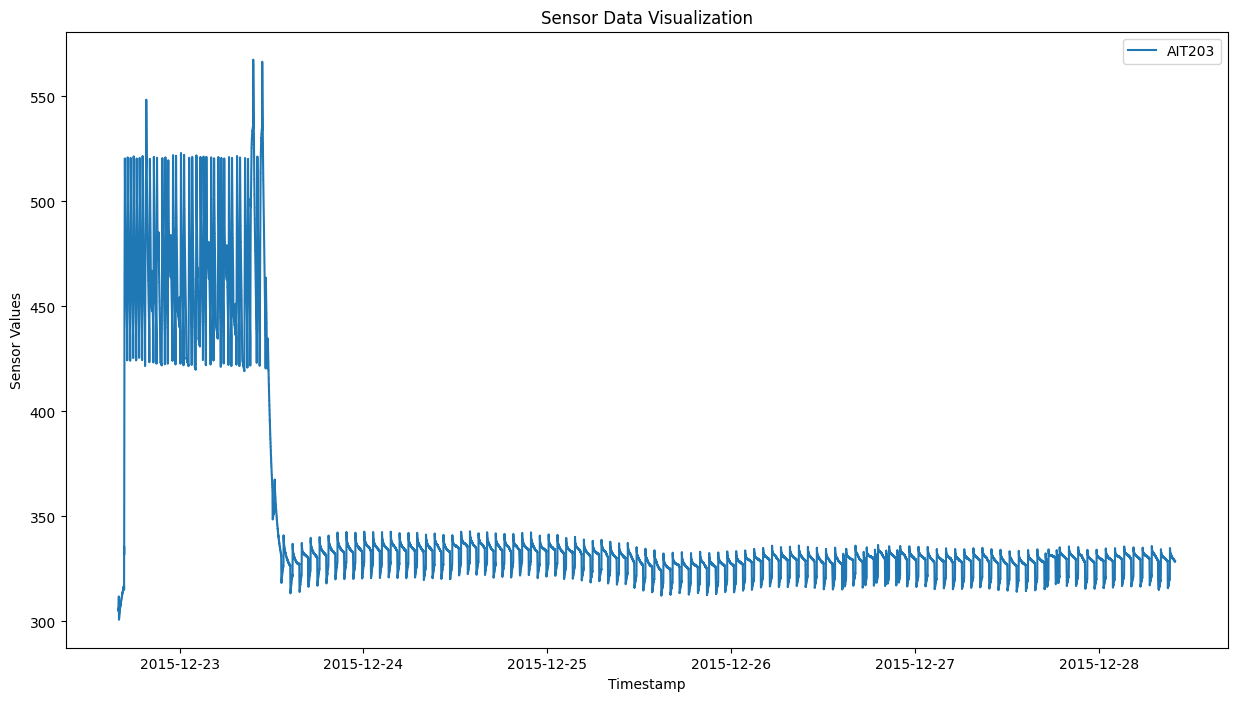

In [18]:
visualize_sensor_data(train_data, sensors = ["AIT203"])

This sensor also shows cycling behaviour, but it's interesting to see the difference between the data in the first part regarding to the data sampled after the big dip in the values.

# PCA-based anomaly detection

In this part of the lab, we want to use PCA to find both point anomalies and some collective anomalies. The way this works is that PCA projects data in the directions in which we can keep most of the variance, variance that explains normal datapoints, but **not anomalies!**. This is the approach we are going to take:
<br>
- Standardize data
- Find eigenvectors and eigenvalues of covariance matrix
- Determine k (how many Principal Components we are going to use)
- Project test data onto PCA model
- Find anomalies

*Disclaimer*: We use a lot of methods that parse out nans because as you saw in the covariance matrix, it can happen a lot for constant functions. This can make the PCA look weird, so we just replace them with slightly nicer values or filter them out when needed, in order to make the model fit more correctly.

#### Standardize data

First and foremost, let's make a simple function to get 2 very important values from our data: **the mean and the standar deviation**. These will help us with standardization.

In [19]:
def get_stats(df):
    sensors = df.columns[1:-1]
    data_numeric = df[sensors].apply(pd.to_numeric, errors='coerce')
    
    mean = np.nanmean(data_numeric, axis=0)
    sd = np.nanstd(data_numeric, axis=0)
    sd = np.where(sd == 0, 1, sd)
    
    return mean, sd


Now we can standardize all data using the **z-score**. **Min-Max** standardizing is not an option since it's highly sensitive to outliers. Therefore, we want all data to be centered around 0, with standard deviation 1.

The formula is straight forward:

In [20]:
def apply_z_score(df, mean, sd):
    sensors = df.columns[1:-1]
    data_numeric = df[sensors].apply(pd.to_numeric, errors='coerce')
    
    z_data = (data_numeric - mean) / sd
    return z_data.fillna(0)


#### Eigendecomposition

Next up, we need to get the **eigenvectors** and the **eigenvalues** of the **covariance matrix** of the normalized data. This is important because the eigenvectors will explain the direction of the variation, corresponding to their eigenvalue! So if we want to keep as much variance as possible, we just project the dataset onto the space described by the *eigenvectors with highest corresponding eigenvalues!*

Let's create the **covariance matrix**- we also did this in the Familiarization part.

In [21]:
def covariance_matrix(data):

    matrix = np.corrcoef(data.T)
    matrix = np.where(np.isnan(matrix), 0.0, matrix)

    return matrix

Now, let's write a function to get the eigenvalues and eigenvectors of a matrix, sorted by *descending eigenvalues*.

In [22]:
def eigendecomposition(data):
    mean, sd = get_stats(data)
    normalized_data = apply_z_score(data, mean, sd)
    matrix = covariance_matrix(normalized_data)

    eigenvalues, eigenvectors = np.linalg.eig(matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    return (sorted_eigenvalues, sorted_eigenvectors)

#### How many Principal Components are we projecting onto?

/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


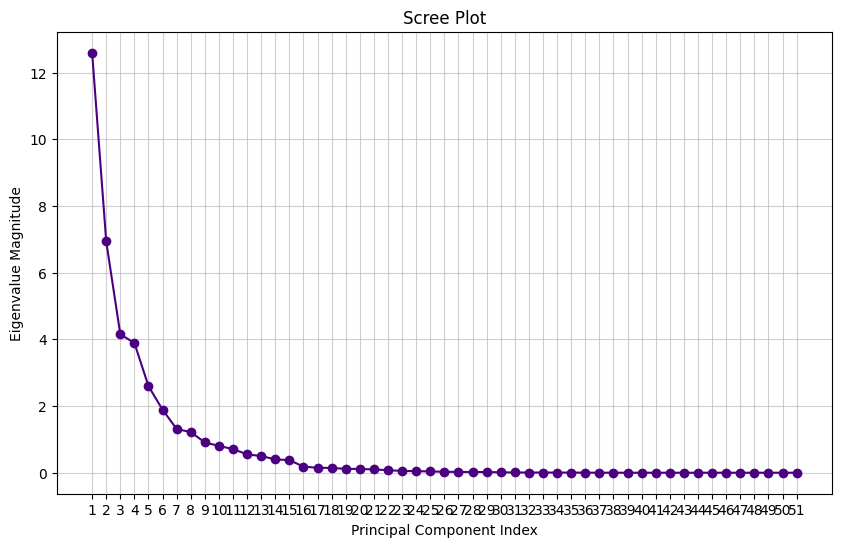

In [23]:
eigenvalues, eigenvectors = eigendecomposition(train_data)

component_indices = np.arange(1, len(eigenvalues) + 1)

plt.figure(figsize=(10, 6))
plt.plot(component_indices, eigenvalues, 
         marker='o',             
         linestyle='-',          
         color='indigo')

plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue Magnitude')
plt.title('Scree Plot')
plt.xticks(component_indices)
plt.grid(True, alpha=0.6)

plt.show()

Now that we have the elbow graph plotte, we have to pick the **k** with the biggest *index to magnitude ratio*. In visual terms, we have to pick the k that is closest to the bottom left, which are Principal Component Indexes 5 and 6. 

#### Projecting phase

Let's define a function that will help us make a model of the PCA for a given dataset. We want to get the mean, standard deviation, number of principal components, eigenvalues, and variance.

We also need to define the threshold, so let's write a couple of functions for different ways to compute this.

In [24]:
def get_threshold_mean_sd(residuals):
    return np.mean(residuals) + 3 * np.std(residuals)

def get_threshold_variance(residuals, variance_threshold):
    return np.percentile(residuals, variance_threshold)

def train_pca_model(df, k, variance_threshold = 99.5):
    sensors = df.columns[1:-1]
    data_numeric = df[sensors].apply(pd.to_numeric, errors='coerce')

    mean, sd = get_stats(df)
    norm_train = apply_z_score(df, mean, sd)
    
    _, eigenvectors = eigendecomposition(df)
    
    P_k = eigenvectors[:, :k]
    scores = np.dot(norm_train, P_k)
    reconstructed = np.dot(scores, P_k.T)
    residuals = norm_train - reconstructed
    q_scores_train = np.sum(np.square(residuals), axis=1)

    q_limit = get_threshold_variance(q_scores_train, variance_threshold)
    
    return {
        'mean': mean,
        'sd': sd,
        'eigenvectors': eigenvectors,
        'k': k,
        'q_limit': q_limit
    }

Almost done! Now that we have a function to create a PCA model based on the data feeded into it, we just need a function that, given the model and some data, to give us the anomalies! This is fairly simple to implement now that we have our model nicely coded.

In [25]:
def predict_anomalies(test_df, model):
    norm_test = apply_z_score(test_df, model['mean'], model['sd'])
    
    P_k = model['eigenvectors'][:, :model['k']]
    
    scores = np.dot(norm_test, P_k)
    
    reconstructed = np.dot(scores, P_k.T)
    
    residuals = norm_test - reconstructed
    q_scores_test = np.sum(np.square(residuals), axis=1)
    
    anomalies = q_scores_test > model['q_limit']
    
    return q_scores_test, anomalies

Finally, let's see some plots. How does our model do on the train data?

/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


limit is: {} 182.56420938184806
anomalies found: {} 2484


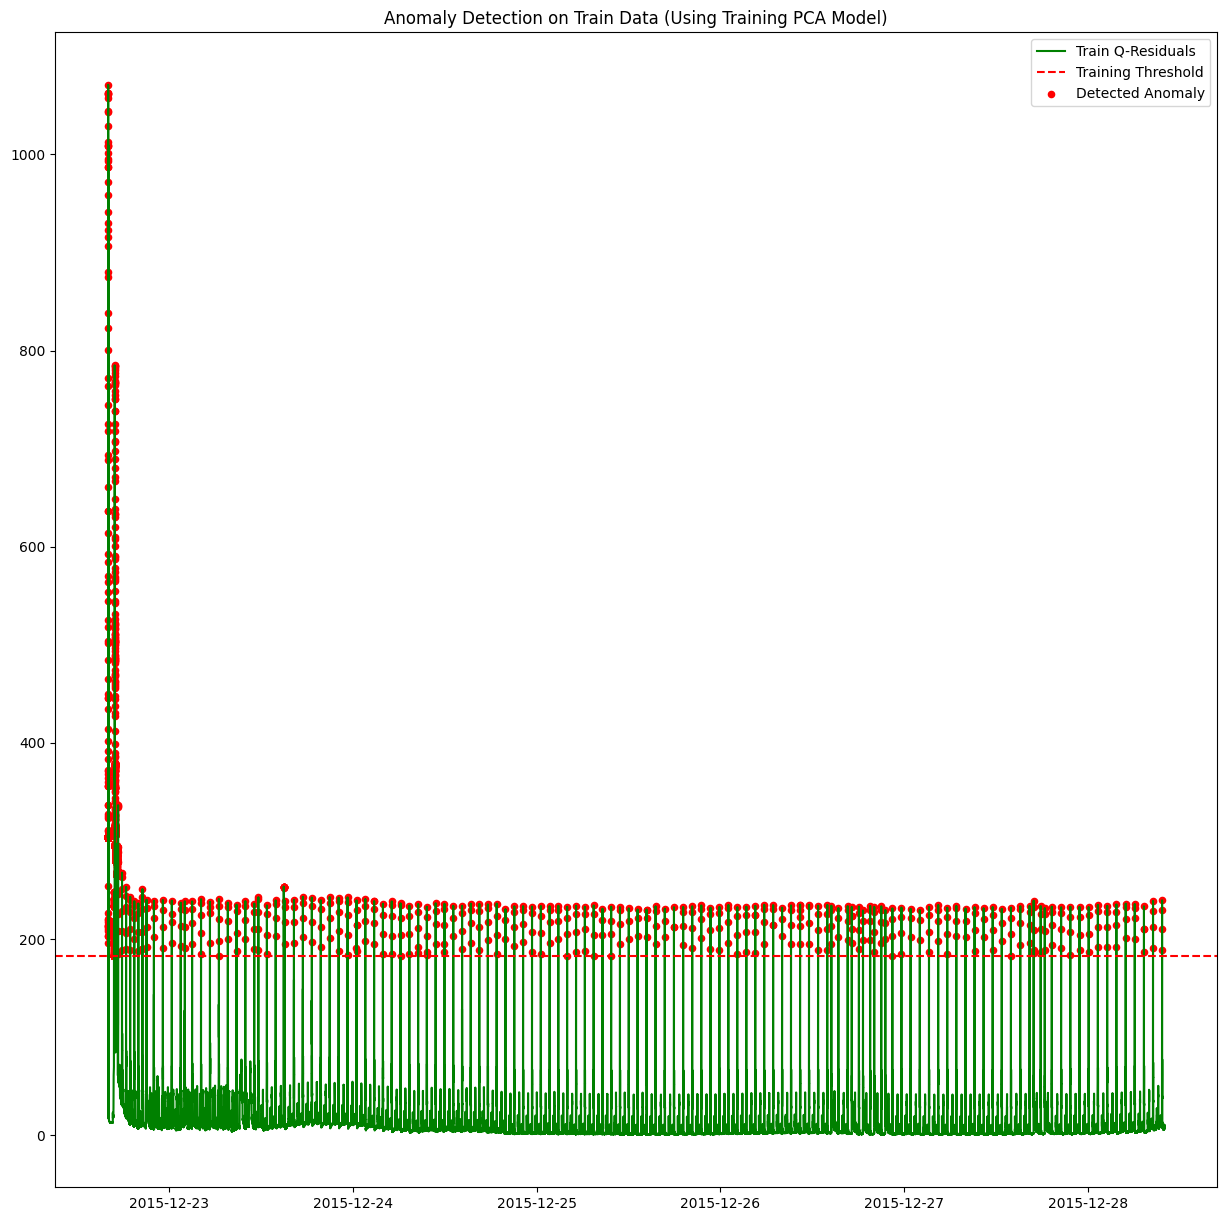

In [26]:
def pca_for_train(k, variance_threshold):
    model_params = train_pca_model(train_data, k, variance_threshold)
    train_q_scores, train_anomalies = predict_anomalies(train_data, model_params)

    print("limit is: {}", model_params["q_limit"])
    print("anomalies found: {}", np.shape(np.where(train_anomalies == True))[1])

    plt.figure(figsize=(15, 15))
    plt.plot(train_data['Timestamp'], train_q_scores, label='Train Q-Residuals', color='green')
    plt.axhline(y=model_params['q_limit'], color='red', linestyle='--', label='Training Threshold')
    detected_points = train_data[train_anomalies]
    plt.scatter(detected_points['Timestamp'], train_q_scores[train_anomalies], color='red', s=20, label='Detected Anomaly')

    plt.title('Anomaly Detection on Train Data (Using Training PCA Model)')
    plt.legend()
    plt.show()

pca_for_train(5, 99.5)

As you can see, our model does pretty good! We would like to have the limit just a little bit higher though, so let's also try different options for k and the variation_threshold, around the optimal values.

/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


limit is: {} 383.6237954018671
anomalies found: {} 2484


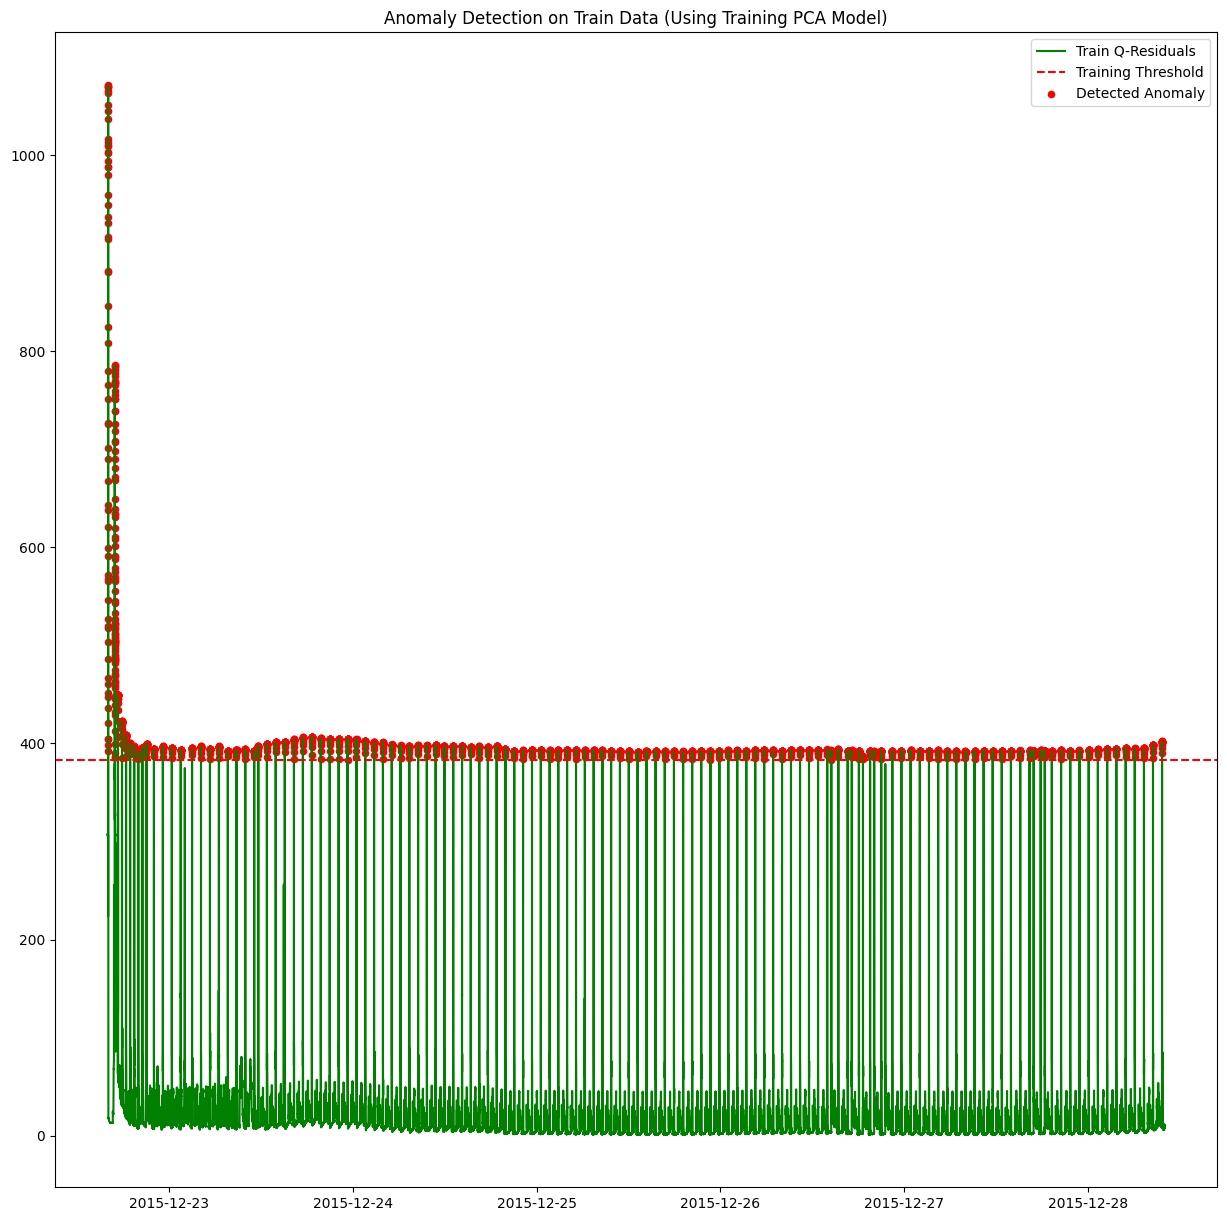

In [27]:
pca_for_train(3, 99.5)

This looks perfect! Now it's very easy to see how this model does on our test data.

#### Finding the anomalies

It's that we separated the concerns in the way that we did, because now it's very simple to apply the model to a different data set. **It's basically the same process as for building the model, but with the data variable changed!**
Let's take a look.

/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/luca23bledea/Library/Mobile Documents/com~apple~CloudDocs/Downloads/University Year 2/Y2 Q3/Computational Intelligence/project_team60/ci-assignment-1/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


limit is {} 383.6237954018671
anomalies found {} 56045


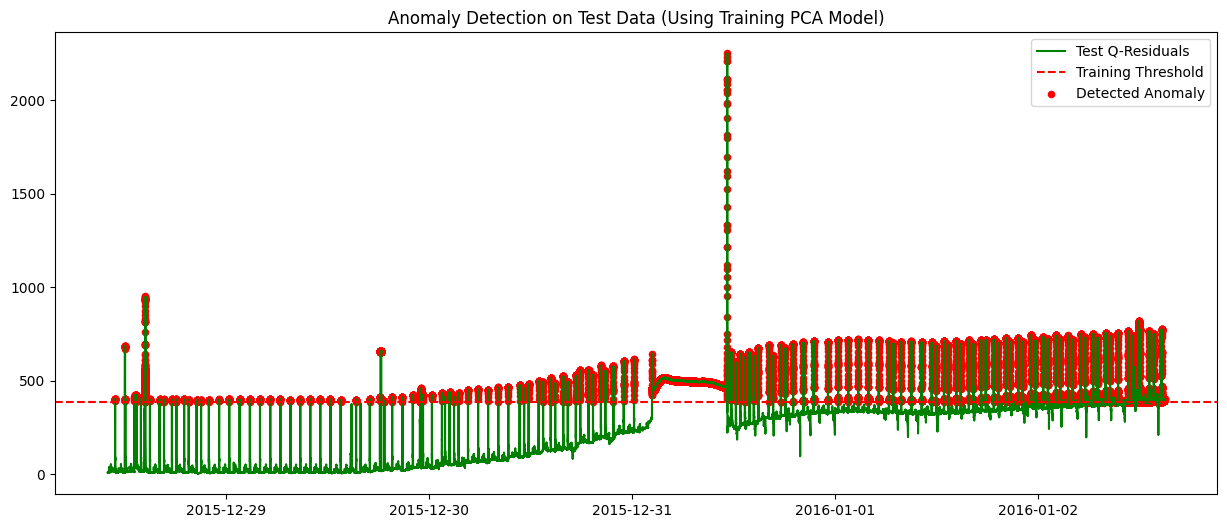

In [28]:
def pca_for_test(k, variance_threshold):
    model_params = train_pca_model(train_data, k, variance_threshold)
    test_q_scores, test_anomalies = predict_anomalies(test_data, model_params)

    print("limit is {}", model_params['q_limit'])
    print("anomalies found {}", np.shape(np.where(test_anomalies == True))[1])

    plt.figure(figsize=(15, 6))
    plt.plot(test_data['Timestamp'], test_q_scores, label='Test Q-Residuals', color='green')
    plt.axhline(y=model_params['q_limit'], color='red', linestyle='--', label='Training Threshold')
    detected_points = test_data[test_anomalies]
    plt.scatter(detected_points['Timestamp'], test_q_scores[test_anomalies], color='red', s=20, label='Detected Anomaly')
    plt.title('Anomaly Detection on Test Data (Using Training PCA Model)')
    plt.legend()
    plt.show()

pca_for_test(3, 99.5)

### Conclusion

Finding anomalies through PCA is not difficult; actually, there is a step by step and very intuitive guide you have to follow. Once you know that the variance of the outliers is not explained by the PCA, it's somewhat simple to imagine how this might work, and these plots explain just that.

# DTW-based anomaly detection

For this assignment, given what we've analyzed at the last exercise, we've chosen the **AIT203** sensor. This is mainly because the AIT203 sensor displays clear and interesting temporal behaviour, including periodic oscilations, sudden spikes, and long term trends; these characteristics making window-based DTW very suitable in finding abnormalities.

### The DTW algorithm (fast)

We used a fast-DTW algorithm as we had to wait a long time in the first few runtimes, to compute the values. The choice of k was 10, so we could significantly speed up the implementation. 

**Why k=10?** Because it limits temporal warping to ±10 samples, which is appropriate for AIT203 since its oscillations are regular and smooth. Extreme time distortions (e.g., >20 sample shifts) are physically unrealistic for this sensor's slow cyclical behavior. This reduces DTW complexity from O(n²m²) to O(n×m×k).

In [29]:
def dynamic_time_warping(a, b, k):
    n = a.size
    m = b.size
    k = max(k, abs(n - m))
    
    # Initialize distance matrix with infinity
    dtw_distance = np.inf
    d = [[dtw_distance for _ in range(m + 1)] for _ in range(n + 1)]
    
    # Base case: distance from start point
    d[0][0] = 0
    
    # Compute DTW distance using dynamic programming
    for i in range(1, n + 1):
        j_start = max(1, i - k)
        j_end = min(m, i + k)

        for j in range(j_start, j_end+1):
            cost = abs(a[i - 1] - b[j - 1])
            d[i][j] = cost + min(d[i - 1][j], min(d[i][j - 1], d[i - 1][j - 1]))
    
    # Return square root of final distance
    return np.sqrt(d[n][m])

Using DTW distances on sliding windows mainly detects **collective anomalies**, so this is what we expect. However, it could also indirectly identify point and contextual anomalies whenever the windows disrupt the expected temporal shape of the signal.

### Sliding window creation

In [30]:
def create_sliding_windows(signal, window_size, stride):
    windows = []
    indices = []

    for i in range(0, len(signal) - window_size + 1, stride):
        windows.append(signal[i:i + window_size])
        indices.append(i)

    return windows, indices

### Compute Residual Distance

In [31]:
def compute_residuals(windows, repr_windows, r=10):
    residuals = []

    for w in windows:
        min_dist = float('inf')

        for rwin in repr_windows:
            dist = dynamic_time_warping(w, rwin, r)
            if dist < min_dist:
                min_dist = dist

        residuals.append(min_dist)

    return np.array(residuals)


### Put everything together

Again, we discovered that DTW is very expensive computationally as comparing each window to all other windows would be too slow. To reduce runtime, we build a subset of representative windows by taking every 10th window from the training data. <br>
This mainly preserves the structure, while reducing the computations by around 10x.

In [32]:
def compute_dtw_residuals(train_data, test_data, sensor="AIT203", window_size=150, stride=1000, repr_step=10):

    # Extract AIT203 sensor
    ait203_train = train_data[sensor].values
    ait203_test = test_data[sensor].values

    # take every 3rd sample
    # ait203_train = ait203_train[::3]
    # ait203_test = ait203_test[::3]

    # Generate windows
    train_windows, train_idx = create_sliding_windows(ait203_train, window_size, stride)
    test_windows, test_idx = create_sliding_windows(ait203_test, window_size, stride)

    repr_train_windows = train_windows[::repr_step]     # every 10th window as representative

    # Compute DTW residuals
    train_res = compute_residuals(train_windows, repr_train_windows)
    test_res  = compute_residuals(test_windows, repr_train_windows )

    return train_res, test_res, train_idx, test_idx

### Plot the train and test residuals

In [33]:
def visualize_dtw_analysis(train_data, test_data, train_res, test_res, 
                          train_idx, test_idx, sensor='AIT203'):
    # Calculate threshold from training residuals
    train_mean = np.mean(train_res)
    train_std = np.std(train_res)
    threshold = train_mean + 2 * train_std

    # ========================================================================
    # Plot 1: TRAINING DATA with Residuals
    # ========================================================================

    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Left y-axis: Raw sensor signal (blue)
    color_signal = 'tab:blue'
    ax1.set_xlabel('Timestamp', fontsize=12)
    ax1.set_ylabel(f'{sensor} Sensor Value', color=color_signal, fontsize=12)
    ax1.plot(train_data['Timestamp'], train_data[sensor], 
             color=color_signal, alpha=0.5, linewidth=0.5, label=f'{sensor} Signal')
    ax1.tick_params(axis='y', labelcolor=color_signal)
    ax1.grid(True, alpha=0.3)

    # Right y-axis: DTW residuals (red)
    ax2 = ax1.twinx()
    color_residual = 'tab:red'
    ax2.set_ylabel('DTW Distance (Residual)', color=color_residual, fontsize=12)
    ax2.plot(train_data['Timestamp'].iloc[train_idx], train_res, 
             color=color_residual, linewidth=1.5, alpha=0.8, label='DTW Residuals')
    ax2.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Threshold ({threshold:.1f})')
    ax2.tick_params(axis='y', labelcolor=color_residual)

    # Title and legends
    plt.title(f'Training Data: {sensor} Signal and DTW Residuals (Baseline)', 
              fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax2.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # Plot 2: TEST DATA with Residuals and Anomalies
    # ========================================================================

    # Detect anomalies
    anomaly_mask = test_res > threshold
    num_anomalies = np.sum(anomaly_mask)
    anomaly_rate = num_anomalies / len(test_res) * 100

    fig, ax1 = plt.subplots(figsize=(15, 6))

    # Left y-axis: Raw sensor signal (blue)
    ax1.set_xlabel('Timestamp', fontsize=12)
    ax1.set_ylabel(f'{sensor} Sensor Value', color=color_signal, fontsize=12)
    ax1.plot(test_data['Timestamp'], test_data[sensor], 
             color=color_signal, alpha=0.5, linewidth=0.5, label=f'{sensor} Signal')
    ax1.tick_params(axis='y', labelcolor=color_signal)
    ax1.grid(True, alpha=0.3)

    # Right y-axis: DTW residuals (red)
    ax2 = ax1.twinx()
    ax2.set_ylabel('DTW Distance (Residual)', color=color_residual, fontsize=12)
    ax2.plot(test_data['Timestamp'].iloc[test_idx], test_res, 
             color=color_residual, linewidth=1.5, alpha=0.8, label='DTW Residuals')
    ax2.axhline(y=threshold, color='orange', linestyle='--', linewidth=2.5, 
                alpha=0.8, label=f'Threshold ({threshold:.1f})')

    # Highlight anomalies with red X markers
    if num_anomalies > 0:
        anomaly_timestamps = test_data['Timestamp'].iloc[test_idx].values[anomaly_mask]
        anomaly_distances = test_res[anomaly_mask]
        ax2.scatter(anomaly_timestamps, anomaly_distances, 
                   color='darkred', s=60, marker='x', linewidths=2,
                   zorder=5, label=f'Anomalies ({num_anomalies})', alpha=0.9)

    ax2.tick_params(axis='y', labelcolor=color_residual)

    # Title and legends
    plt.title(f'Test Data: {sensor} Signal, DTW Residuals, and Detected Anomalies', 
              fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax2.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

- ### Window size = 150, stride = 1000

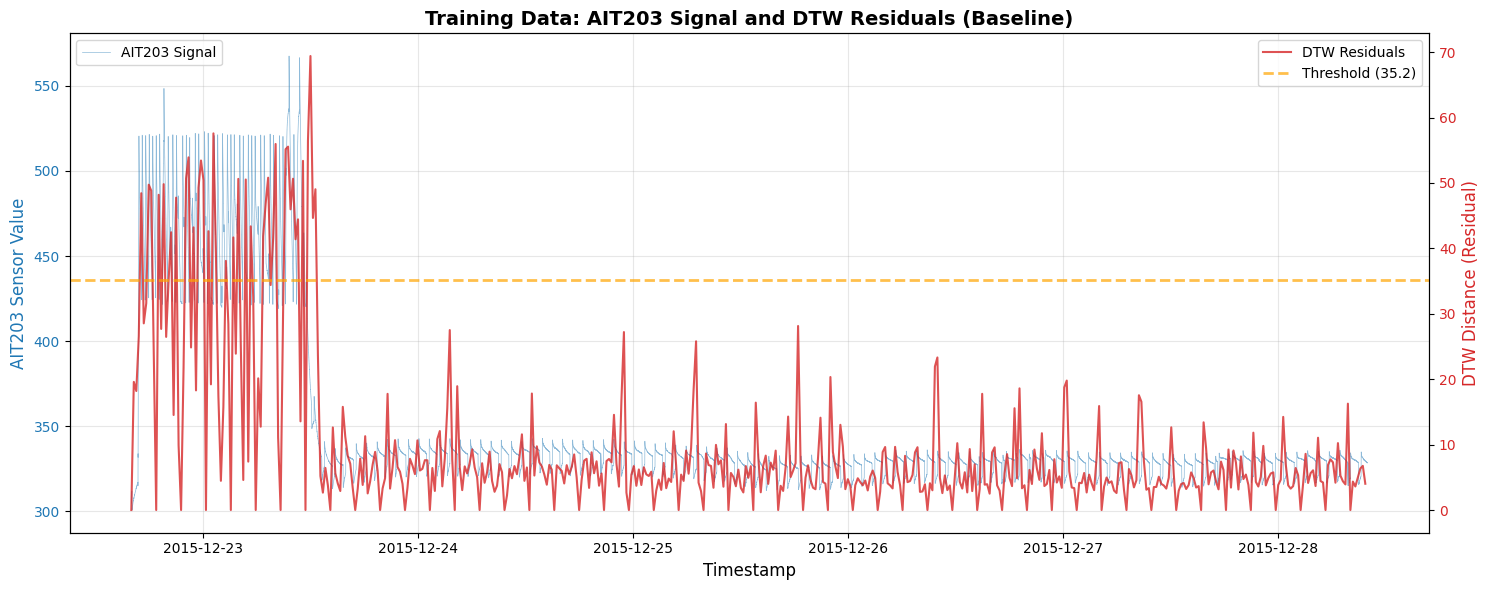

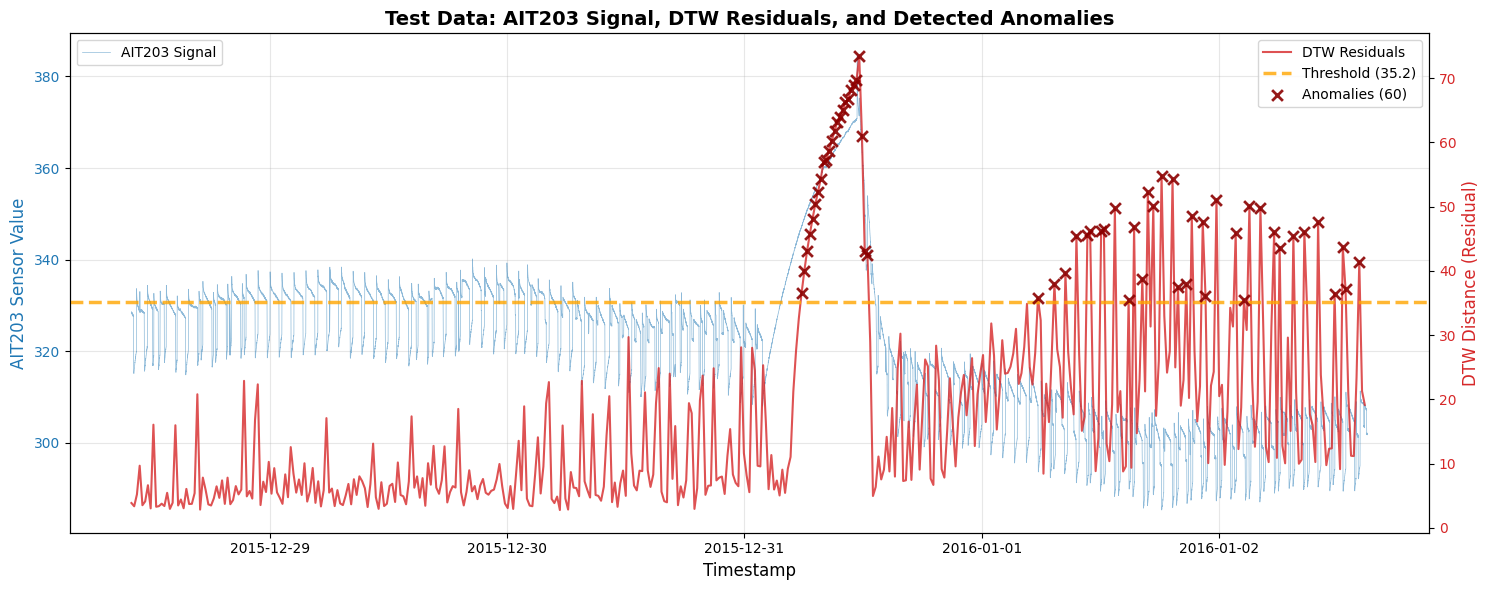

In [34]:
train_res, test_res, train_idx, test_idx = compute_dtw_residuals(train_data, test_data, window_size=150, stride=1000)
visualize_dtw_analysis(train_data, test_data, train_res, test_res, train_idx, test_idx, "AIT203")

DTW residuals over 150-point windows show stable behavior in training data, with moderate noise around a baseline.<br>
In test data, a large spike around Dec 31–Jan 1 is clearly detected as a collective anomaly, representing a multi-hour deviation. Later drifts on Jan 1–2 are also flagged, indicating sustained abnormal behavior.<br>
Detected anomaly types:
- collective anomalies as talked about above
- contextual anomalies appear when similar ranges show different trend shapes
- point anomalies are not detected because of the long window
<br>
Overall, this configuration is effective for detecting shape changes, provides good sensitivity, a moderate number of detections, and manageable false alarms.

- ### Window size = 300, stride = 1000

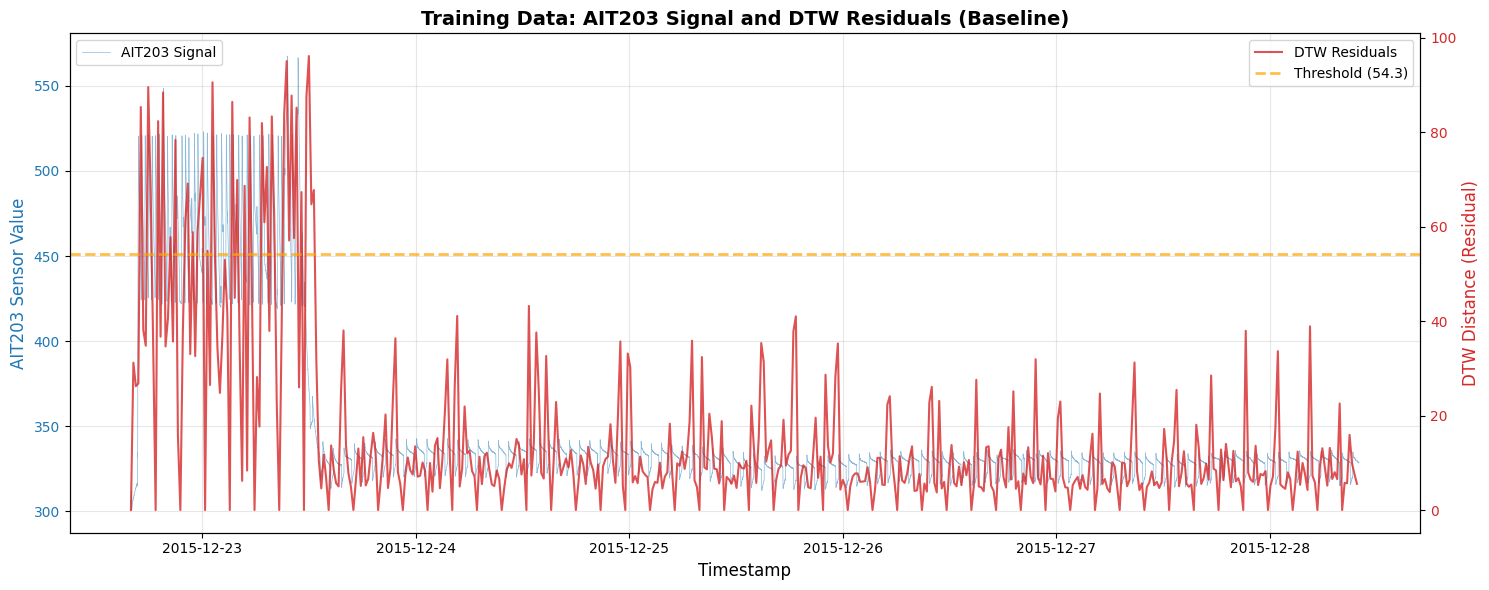

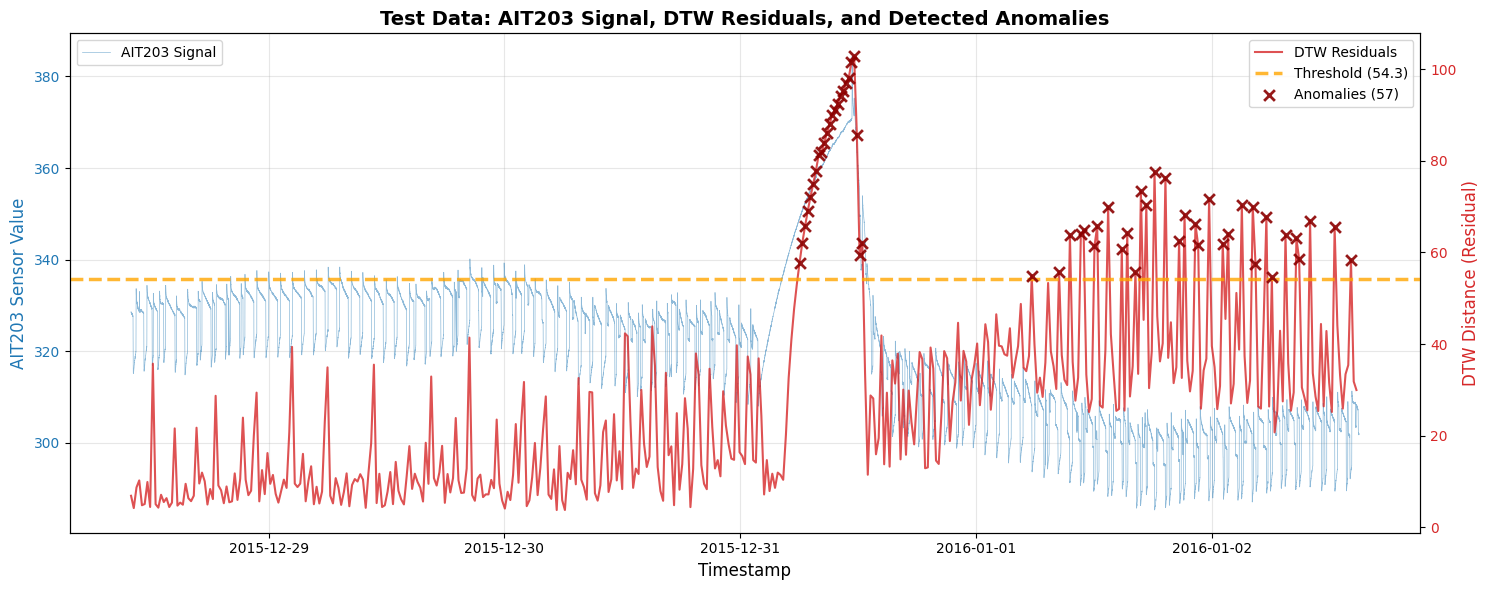

In [35]:
train_res, test_res, train_idx, test_idx = compute_dtw_residuals(train_data, test_data, window_size=300, stride=1000)
visualize_dtw_analysis(train_data, test_data, train_res, test_res, train_idx, test_idx, "AIT203")

DTW residuals with a window size of 300 and stride of 1000 show slightly higher training residuals due to larger windows.<br>
In test data, the large deviation around Dec 31 is still detected, but fewer anomalies appear around Jan 1–2.
<br>Detected anomaly types:
- collective are captured best as long windows emphasize multi-window deviations and regime changes
- (some) contextual anomalies are detected, but fewer than with shorter windows because longer windows enforce consistency
- point anomalies are not detected since single spikes are smoothed out
<br>
Overall, this configuration is the most stable, with low sensitivity. It misses subtle or short events but is ideal for reducing false alarms and focusing on severe drift.

- ### Window size = 150, stride = 3000


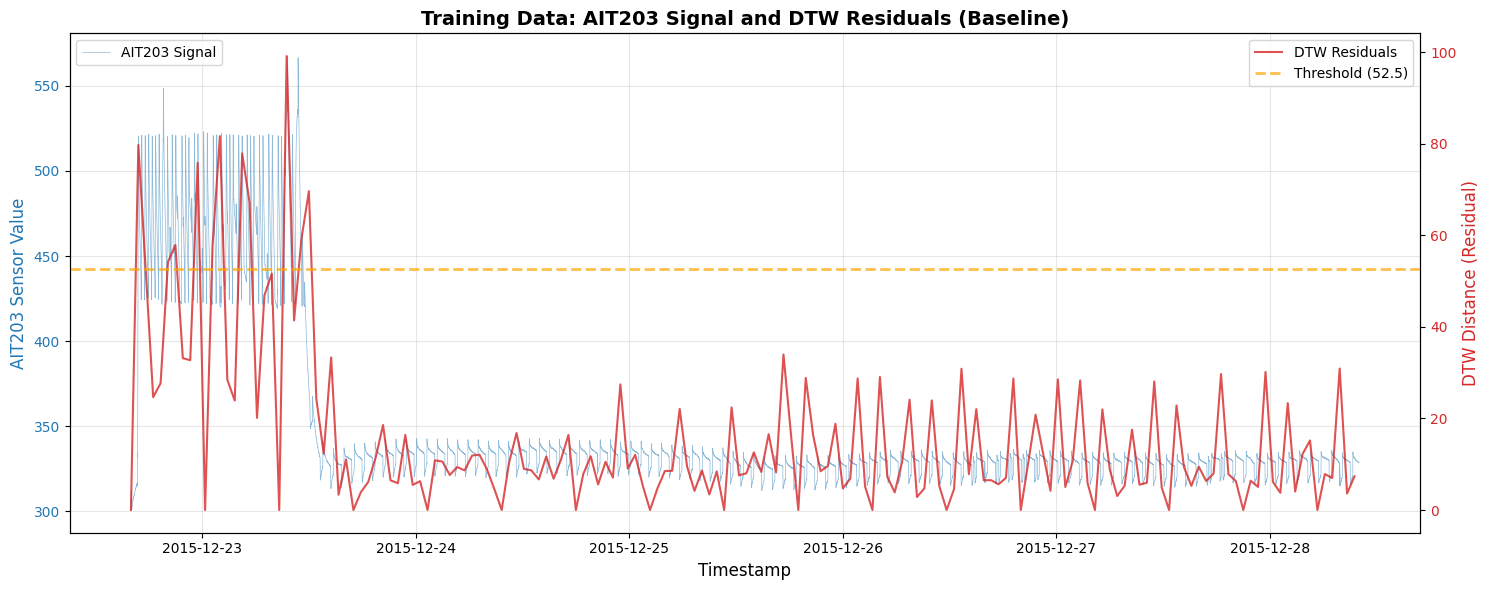

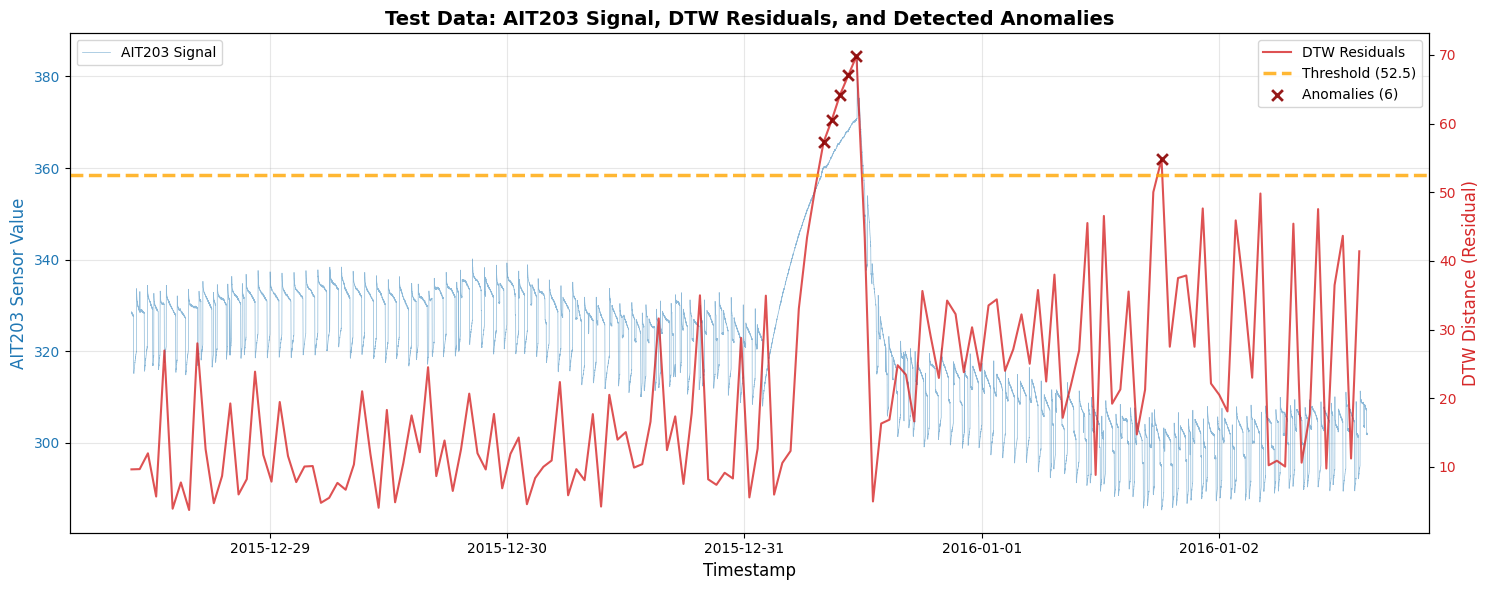

In [36]:
train_res, test_res, train_idx, test_idx = compute_dtw_residuals(train_data, test_data, window_size=150, stride=3000)
visualize_dtw_analysis(train_data, test_data, train_res, test_res, train_idx, test_idx, "AIT203")

DTW residuals with stride 3000 produce training residuals of similar shape but with fewer windows, making the representation coarse.
<br>In test data, the large anomaly around Dec 31 is detected, but most subsequent anomalies are missed because the stride skips large portions of the signal. Only about six anomalies are identified.
<br>Detected anomaly types:
- large collective anomalies are captured, as only multi-hour deviations are visible
- contextual anomalies are not detected since the stride is too large and windows barely overlap
- point anomalies are completely ignored
<br>
Overall, this setup is fast but sacrifices resolution. The large gaps between windows prevent detection of fine-grained abnormal behavior. It is suitable only when runtime efficiency is more important than sensitivity.

#### Conclusion
After experimenting with three configurations, we rank them as follows: **(1) w=150, s=1000** -> best overall, **(2) w=300, s=1000** —> conservative but precise, **(3) w=150, s=3000** —> fast but too sparse. The first configuration provides the best balance between anomaly detectability (collective + contextual), false alarms, and runtime: 150-sample windows capture meaningful temporal shapes while stride 1000 limits DTW computations to a feasible number. The second configuration reduces false positives but oversmoothes short anomalies, and the third trades detection for speed. Therefore w=150, s=1000 is our recommended setting.